In [25]:
from pandas import read_csv
from matplotlib import pyplot as plt
import pandas as pd
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
import xml.etree.ElementTree as ET
import numpy as np

In [20]:
series = read_csv('../DataFrames/daily-min-temperatures.csv', header=0, index_col=0, parse_dates=True)
print(series.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


<Axes: xlabel='Date'>

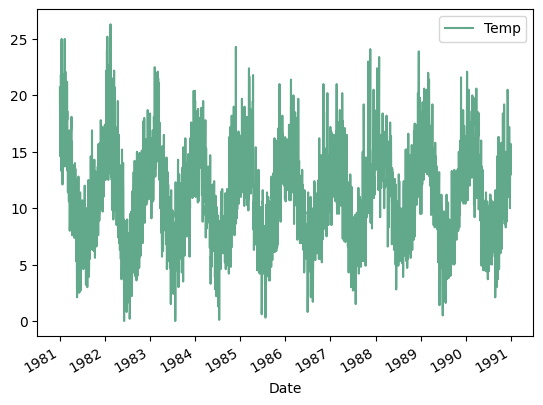

In [21]:
series.plot(color="#62a88b")

<Axes: xlabel='Date'>

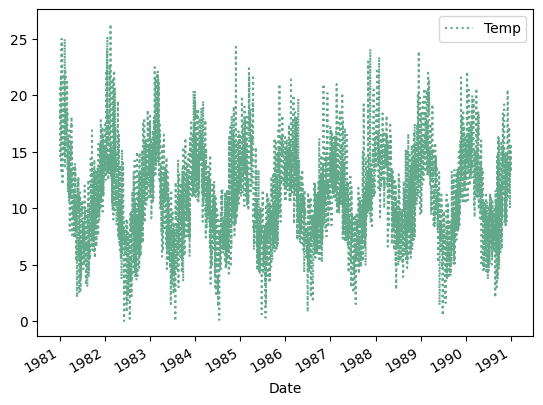

In [22]:
series.plot(style=":", color="#62a88b")

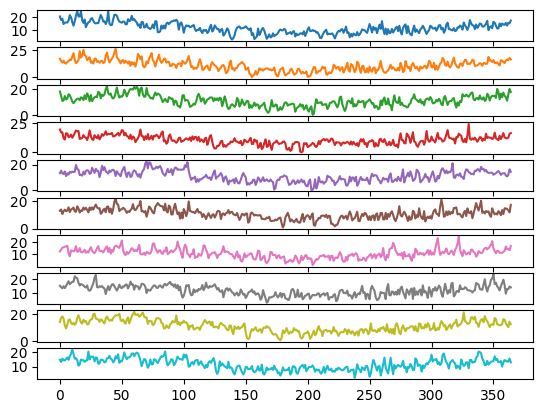

In [28]:
# Assuming 'series' is a pandas Series with a datetime index
groups = series.groupby(series.index.year)

years = pd.concat([pd.Series(x.values.flatten(), name=y) for y, x in groups], axis=1)

axes = years.plot(subplots=True, legend=False)

# Add titles to each subplot
#for ax, year in zip(axes, years.columns):
#   ax.set_title(str(year))

plt.show()

array([[<Axes: title={'center': 'Temp'}>]], dtype=object)

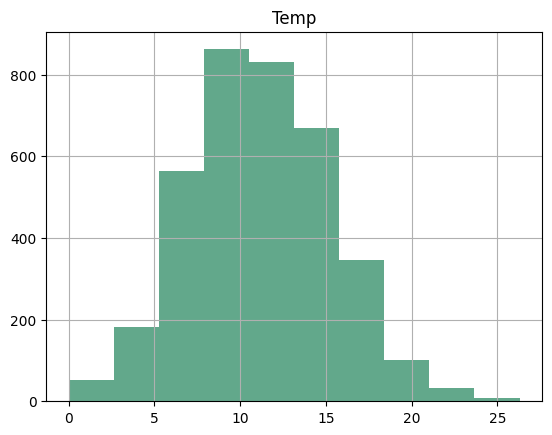

In [29]:
series.hist(color="#62a88b")

<Axes: >

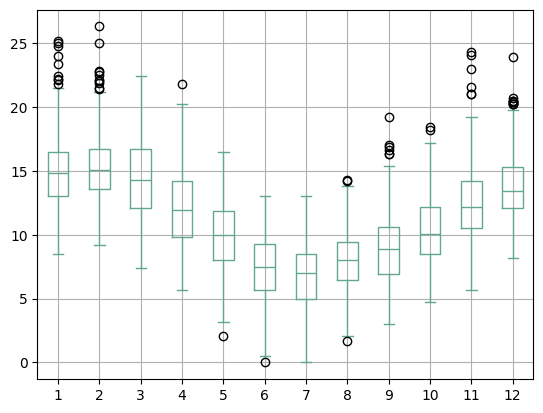

In [40]:
# boxplot por ano
groups = series.groupby(series.index.month)
months = pd.concat([pd.Series(x.values.flatten(), name=y) for y, x in groups], axis=1)
months.boxplot(color="#62a88b")

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

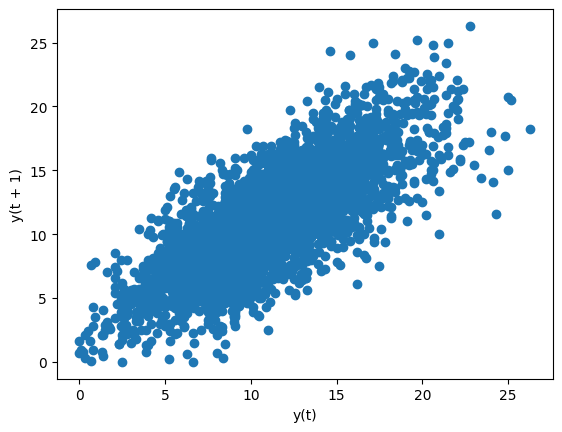

In [ ]:
lag_plot(series, lag=1)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

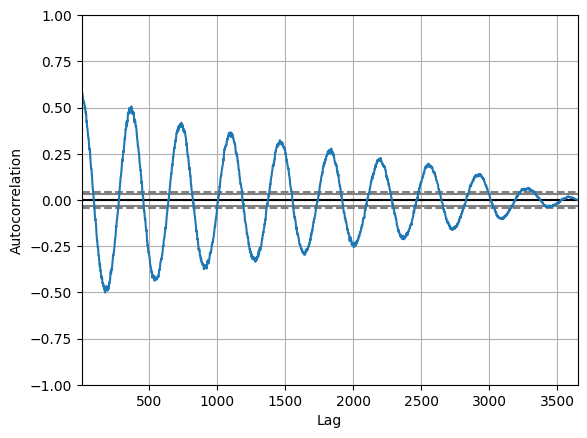

In [47]:
autocorrelation_plot(series)

In [3]:
peso_professor_df = pd.read_csv("../DataFrames/peso_professor.csv", sep=",")

peso_professor_df.head()

,data,peso (kg)
0,01/01/2025,80.7
1,02/01/2025,80.7
2,03/01/2025,79.8
3,04/01/2025,79.2
4,05/01/2025,80.0


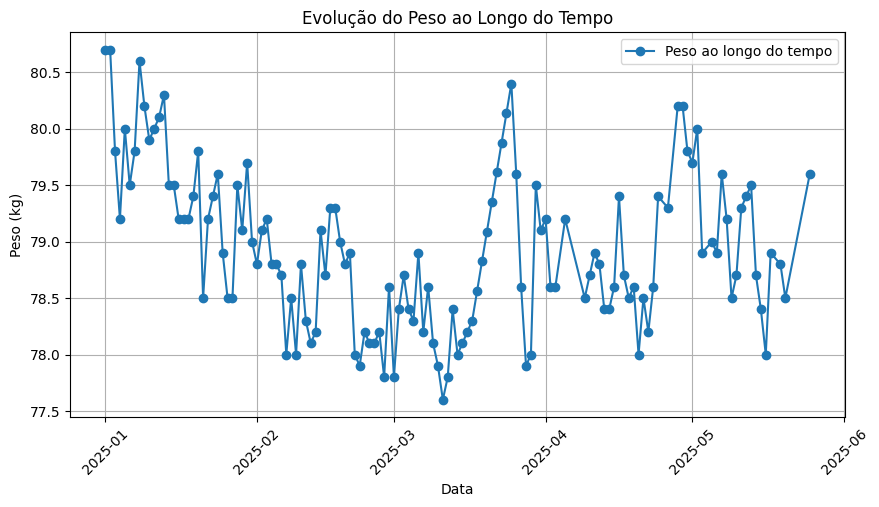

In [11]:
# prompt: Escreva código python que plota, para o dataframe peso_professor_df,
# a série temporal do campo "peso (kg)" ao longo do tempo, contido na coluna "data".

# Certifique-se de que a coluna 'data' está no formato datetime
peso_professor_df['data'] = pd.to_datetime(peso_professor_df['data'], format="%d/%m/%Y")

# Ordenar o DataFrame por data
peso_professor_df = peso_professor_df.sort_values(by='data')

# Plotando a série temporal
plt.figure(figsize=(10, 5))
plt.plot(peso_professor_df['data'], peso_professor_df['peso (kg)'], marker='o', linestyle='-', label='Peso ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Peso (kg)')
plt.title('Evolução do Peso ao Longo do Tempo')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Como posso lidar com dados faltantes em séries temporais?

#peso_professor_df['peso (kg)'].fillna(method='ffill', inplace=True)
#peso_professor_df['peso (kg)'].fillna(method='bfill', inplace=True)
peso_professor_df['peso (kg)'] = peso_professor_df['peso (kg)'].interpolate(method='linear')
# peso_professor_df['peso (kg)'].fillna(peso_professor_df['peso (kg)'].mean(), inplace=True)

In [7]:
# PERGUNTA: o indívíduo está emagrecendo ou não?

peso_professor_df.columns

Index(['data', 'peso (kg)'], dtype='object')

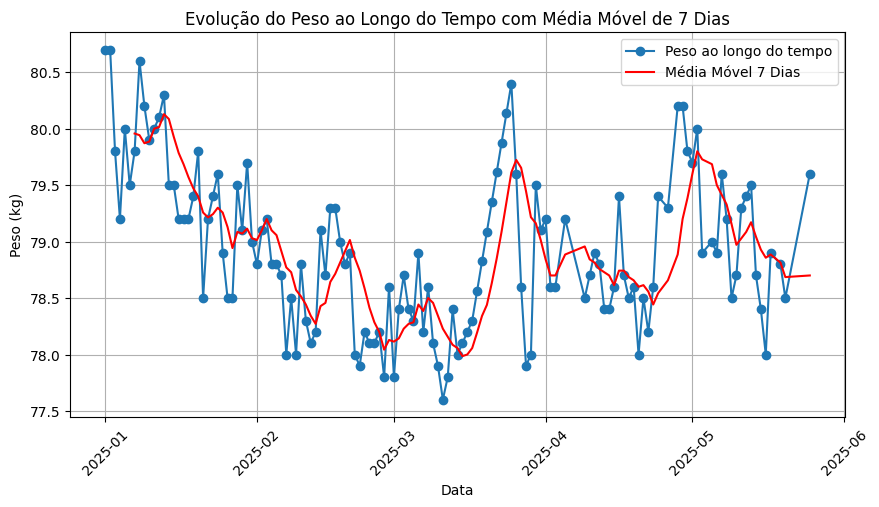

In [12]:
# prompt: Plote a média móvel de 7 dia de "peso (kg)".
# Mantenha a linha original do gráfico.

# Certifique-se de que a coluna 'data' está no formato datetime
peso_professor_df['data'] = pd.to_datetime(peso_professor_df['data'], format='%d/%m/%Y')

# Ordenar o DataFrame por data
peso_professor_df = peso_professor_df.sort_values(by='data')

# Calcular a média móvel de 7 dias
peso_professor_df['media_movel_7d'] = peso_professor_df['peso (kg)'].rolling(window=7).mean()

# Plotando a série temporal original e a média móvel
plt.figure(figsize=(10, 5))
plt.plot(peso_professor_df['data'], peso_professor_df['peso (kg)'], marker='o', linestyle='-', label='Peso ao longo do tempo')
plt.plot(peso_professor_df['data'], peso_professor_df['media_movel_7d'], color='red', linestyle='-', label='Média Móvel 7 Dias')
plt.xlabel('Data')
plt.ylabel('Peso (kg)')
plt.title('Evolução do Peso ao Longo do Tempo com Média Móvel de 7 Dias')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

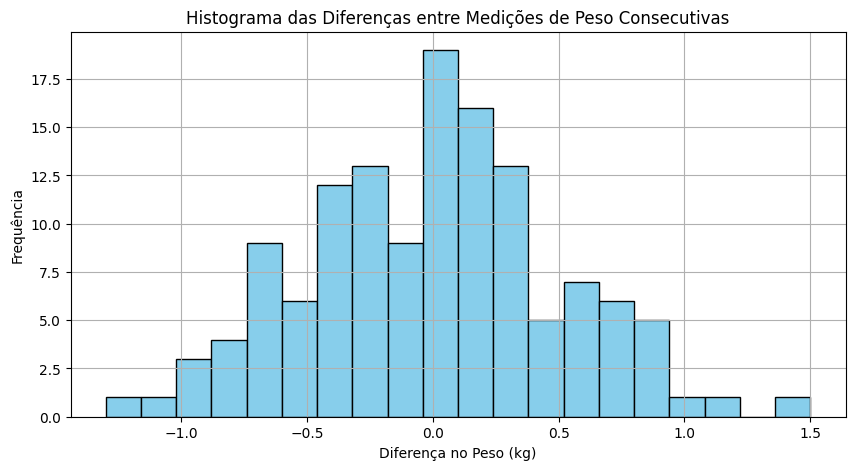

In [13]:
# prompt: Plote um histograma das diferenças entre as medições de peso
# consecutivas.

# Certifique-se de que a coluna 'data' está no formato datetime
peso_professor_df['data'] = pd.to_datetime(peso_professor_df['data'], format='%d/%m/%Y')

# Ordenar o DataFrame por data
peso_professor_df = peso_professor_df.sort_values(by='data')

# Calcular as diferenças entre medições consecutivas de peso
peso_professor_df['diferenca_peso'] = peso_professor_df['peso (kg)'].diff()

# Plotando o histograma das diferenças
plt.figure(figsize=(10, 5))
plt.hist(peso_professor_df['diferenca_peso'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Diferença no Peso (kg)')
plt.ylabel('Frequência')
plt.title('Histograma das Diferenças entre Medições de Peso Consecutivas')
plt.grid(True)
plt.show()

In [10]:
peso_professor_df['diferenca_peso'].mean()

np.float64(-0.008333333333333397)

In [16]:
# Escreva código python que lê o arquivo export.xml do app health do iphone
# para um dataframe pandas.

def parse_health_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    records = []

    for record in root.findall(".//Record"):
        records.append(record.attrib)

    df = pd.DataFrame(records)
    return df

# Substitua 'export.xml' pelo caminho do seu arquivo
file_path = "../DataFrames/export.xml"
df_health = parse_health_xml(file_path)

# Exibe as primeiras linhas do DataFrame
df_health.head()

,type,sourceName,sourceVersion,unit,creationDate,startDate,endDate,value,device
0,HKQuantityTypeIdentifierHeight,Health,14.3,cm,2021-02-02 21:58:29 -0300,2021-02-02 21:58:29 -0300,2021-02-02 21:58:29 -0300,170,NaN
1,HKQuantityTypeIdentifierBodyMass,Health,16.0,kg,2022-09-19 08:35:12 -0300,2022-09-19 08:35:12 -0300,2022-09-19 08:35:12 -0300,60,NaN
2,HKQuantityTypeIdentifierBodyMass,Pedro’s iPhone,17.1.1,kg,2024-01-23 22:21:53 -0300,2024-01-23 22:21:53 -0300,2024-01-23 22:21:53 -0300,63,NaN
3,HKQuantityTypeIdentifierBodyMass,Hevy,1357173,kg,2025-02-11 15:50:19 -0300,2025-02-06 00:00:00 -0300,2025-02-06 00:00:00 -0300,64.7,NaN
4,HKQuantityTypeIdentifierBodyMass,Hevy,1357173,kg,2025-02-11 15:50:30 -0300,2024-11-22 00:00:00 -0300,2024-11-22 00:00:00 -0300,65.1,NaN


In [17]:
df_health['type'].value_counts()

type
HKQuantityTypeIdentifierHeadphoneAudioExposure            165795
HKQuantityTypeIdentifierHeartRate                          87891
HKQuantityTypeIdentifierStepCount                          55165
HKQuantityTypeIdentifierBasalEnergyBurned                  53689
HKQuantityTypeIdentifierDistanceWalkingRunning             50689
HKQuantityTypeIdentifierWalkingSpeed                       32014
HKQuantityTypeIdentifierWalkingStepLength                  32012
HKQuantityTypeIdentifierActiveEnergyBurned                 26006
HKQuantityTypeIdentifierWalkingDoubleSupportPercentage     22411
HKQuantityTypeIdentifierWalkingAsymmetryPercentage         10806
HKQuantityTypeIdentifierFlightsClimbed                      9693
HKCategoryTypeIdentifierSleepAnalysis                       3869
HKQuantityTypeIdentifierAppleWalkingSteadiness               161
HKQuantityTypeIdentifierRestingHeartRate                     129
HKQuantityTypeIdentifierDistanceCycling                       20
HKCategoryTypeIdenti

/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/2263230798.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['value'] = df_filtered['value'].astype(int)


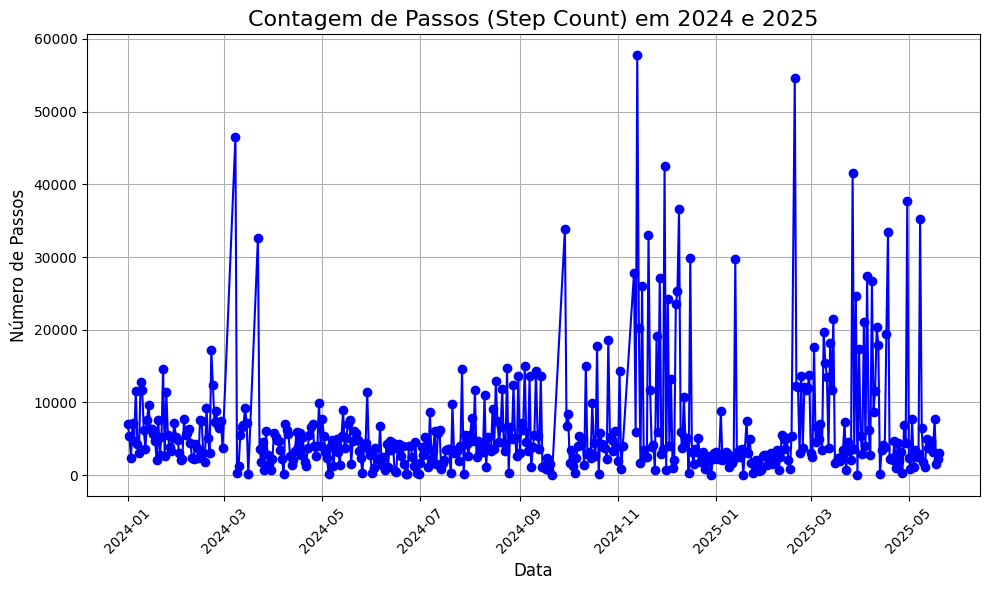

In [19]:
# Converte a coluna creationDate para datetime
df_health['creationDate'] = pd.to_datetime(df_health['creationDate'], format="%Y-%m-%d %H:%M:%S %z")


# Filtra os dados para considerar apenas 2024 e 2025 e tipo HKQuantityTypeIdentifierStepCount
df_filtered = df_health[(df_health['creationDate'].dt.year.isin([2024, 2025])) &
                        (df_health['type'] == 'HKQuantityTypeIdentifierStepCount')]

# Converte a coluna value para inteiro
df_filtered['value'] = df_filtered['value'].astype(int)

# Agrupa os dados por data e soma os valores de steps (valor de "value" para cada data)
df_grouped = df_filtered.groupby(df_filtered['creationDate'].dt.date)['value'].sum().reset_index()

# Converte a coluna de data para o formato de datetime novamente (sem o horário)
df_grouped['creationDate'] = pd.to_datetime(df_grouped['creationDate'])

# Cria o gráfico da série temporal
plt.figure(figsize=(10, 6))
plt.plot(df_grouped['creationDate'], df_grouped['value'], marker='o', linestyle='-', color='b')

# Personaliza o gráfico
plt.title('Contagem de Passos (Step Count) em 2024 e 2025', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Passos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

# Exibe o gráfico
plt.tight_layout()
plt.show()

/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/4179888235.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['value'] = df_filtered['value'].astype(int)


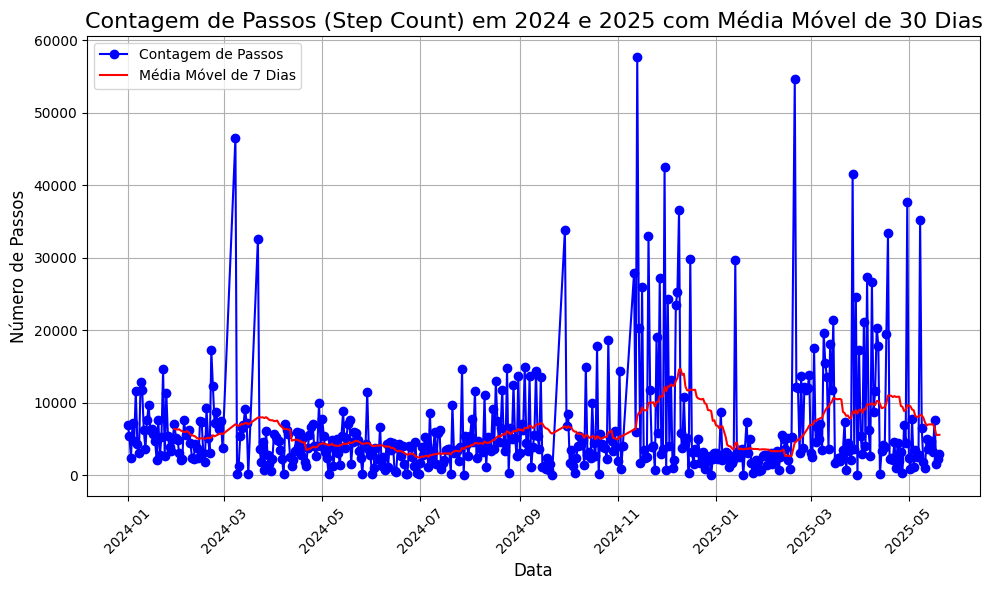

In [20]:
# Adicione ao código anterior a média móvel de 7 dias.

# Converte a coluna creationDate para datetime
df_health['creationDate'] = pd.to_datetime(df_health['creationDate'], format="%Y-%m-%d %H:%M:%S %z")

# Filtra os dados para considerar apenas 2024 e 2025 e tipo HKQuantityTypeIdentifierStepCount
df_filtered = df_health[(df_health['creationDate'].dt.year.isin([2024, 2025])) &
                        (df_health['type'] == 'HKQuantityTypeIdentifierStepCount')]

# Converte a coluna value para inteiro
df_filtered['value'] = df_filtered['value'].astype(int)

# Agrupa os dados por data e soma os valores de steps (valor de "value" para cada data)
df_grouped = df_filtered.groupby(df_filtered['creationDate'].dt.date)['value'].sum().reset_index()

# Converte a coluna de data para o formato de datetime novamente (sem o horário)
df_grouped['creationDate'] = pd.to_datetime(df_grouped['creationDate'])

# Calcula a média móvel de 7 dias
df_grouped['7_day_moving_avg'] = df_grouped['value'].rolling(window=30).mean()

# Cria o gráfico da série temporal
plt.figure(figsize=(10, 6))
plt.plot(df_grouped['creationDate'], df_grouped['value'], marker='o', linestyle='-', color='b', label='Contagem de Passos')
plt.plot(df_grouped['creationDate'], df_grouped['7_day_moving_avg'], linestyle='-', color='r', label='Média Móvel de 7 Dias')

# Personaliza o gráfico
plt.title('Contagem de Passos (Step Count) em 2024 e 2025 com Média Móvel de 30 Dias', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Passos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Exibe o gráfico
plt.tight_layout()
plt.show()

/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/3602835944.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['value'] = df_filtered['value'].astype(int)


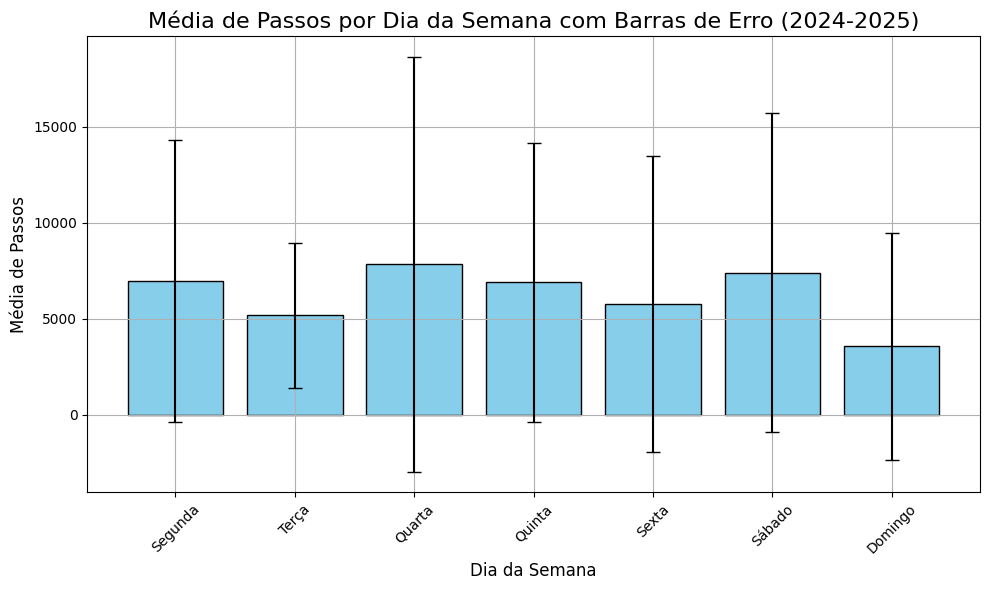

In [21]:
# Gere código que soma os passos em cada dia e, em seguida,
# plota um histograma do número de passos dados em média por dia da semana,
# com barras de erro.

# Converte a coluna creationDate para datetime
df_health['creationDate'] = pd.to_datetime(df_health['creationDate'], format="%Y-%m-%d %H:%M:%S %z")

# Filtra os dados para considerar apenas 2024 e 2025 e tipo HKQuantityTypeIdentifierStepCount
df_filtered = df_health[(df_health['creationDate'].dt.year.isin([2024, 2025])) &
                        (df_health['type'] == 'HKQuantityTypeIdentifierStepCount')]

# Converte a coluna value para inteiro
df_filtered['value'] = df_filtered['value'].astype(int)

# Agrupa os dados por data e soma os valores de passos (valor de "value" para cada data)
df_grouped = df_filtered.groupby(df_filtered['creationDate'].dt.date)['value'].sum().reset_index()

# Converte a coluna de data para o formato de datetime novamente (sem o horário)
df_grouped['creationDate'] = pd.to_datetime(df_grouped['creationDate'])

# Adiciona a coluna do dia da semana (0 = Segunda, 6 = Domingo)
df_grouped['weekday'] = df_grouped['creationDate'].dt.weekday

# Calcula a média de passos por dia da semana
weekly_avg_steps = df_grouped.groupby('weekday')['value'].mean()

# Calcula o desvio padrão de passos por dia da semana para as barras de erro
weekly_std_steps = df_grouped.groupby('weekday')['value'].std()

# Define os rótulos dos dias da semana
days_of_week = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# Cria o gráfico do histograma
plt.figure(figsize=(10, 6))
plt.bar(weekly_avg_steps.index, weekly_avg_steps, yerr=weekly_std_steps, capsize=5, color='skyblue', edgecolor='black')

# Personaliza o gráfico
plt.title('Média de Passos por Dia da Semana com Barras de Erro (2024-2025)', fontsize=16)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Média de Passos', fontsize=12)
plt.xticks(weekly_avg_steps.index, days_of_week, rotation=45)
plt.grid(True)

# Exibe o gráfico
plt.tight_layout()
plt.show()

/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/1620888150.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['value'] = df_filtered['value'].astype(int)
/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/1620888150.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hour'] = df_filtered['creationDate'].dt.hour
/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/1620888150.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of b

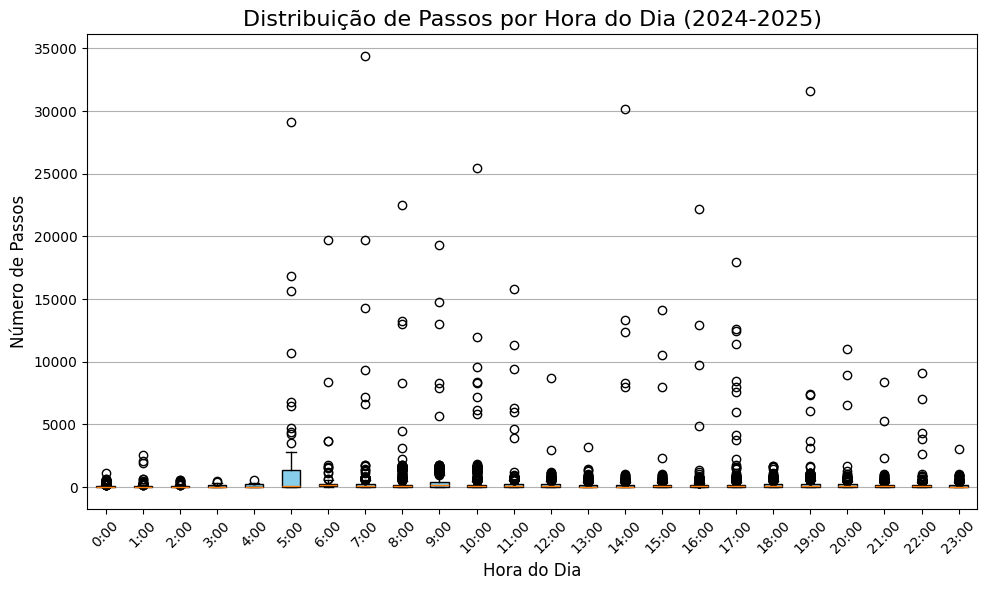

In [26]:
# prompt:
# Por favor, gere código que soma os passos em cada hora de cada data e, em seguida,
# plot os boxplots do número de passos dados em média por hora do dia,
# com barras de erro. Converta 'value' para inteiro.

# Converte a coluna creationDate para datetime
df_health['creationDate'] = pd.to_datetime(df_health['creationDate'], format="%Y-%m-%d %H:%M:%S %z")


# Filtra os dados para considerar apenas 2024 e 2025 e tipo HKQuantityTypeIdentifierStepCount
df_filtered = df_health[(df_health['creationDate'].dt.year.isin([2024, 2025])) &
                        (df_health['type'] == 'HKQuantityTypeIdentifierStepCount')]

# Converte a coluna value para inteiro
df_filtered['value'] = df_filtered['value'].astype(int)

# Agrupa os dados por data e hora, somando os valores de passos (valor de "value" para cada hora de cada data)
df_filtered['hour'] = df_filtered['creationDate'].dt.hour
df_grouped = df_filtered.groupby(['creationDate', 'hour'])['value'].sum().reset_index()

# Cria o boxplot dos passos por hora do dia
plt.figure(figsize=(10, 6))
plt.boxplot([df_grouped[df_grouped['hour'] == h]['value'] for h in range(24)], labels=[f'{h}:00' for h in range(24)], patch_artist=True, boxprops=dict(facecolor='skyblue'))

# Personaliza o gráfico
plt.title('Distribuição de Passos por Hora do Dia (2024-2025)', fontsize=16)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Número de Passos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y')

# Exibe o gráfico
plt.tight_layout()
plt.show()

In [23]:
# Qual o menor valor?
df_filtered['value'].min()

np.int64(1)

/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/3821081438.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['value'] = df_filtered['value'].astype(int)
/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/3821081438.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hour'] = df_filtered['creationDate'].dt.hour
/var/folders/_s/rczzsmpd4kl4kf77y1bwcf600000gn/T/ipykernel_88320/3821081438.py:22: SettingWithCopyWarning: 
A value is trying to be set on a

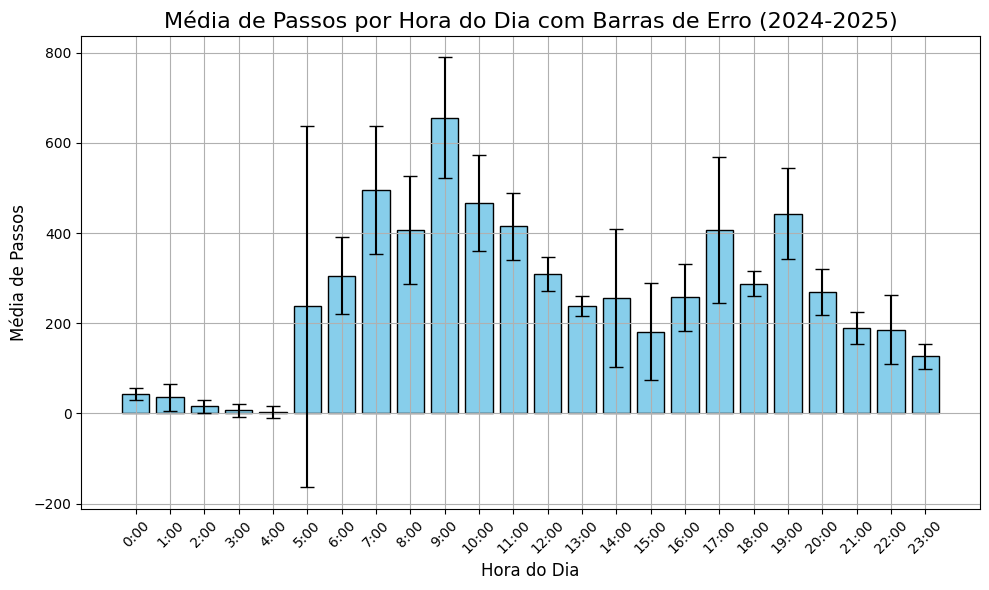

In [27]:
# prompt: Gere código que soma os passos em cada hora de cada data e, em seguida,
# plote os boxplots do número de passos dados em média por hora do dia,
# com barras de erro.
# Converta 'value' para inteiro.
# Lembre-se do seguinte detalhe: o valor 0 não está no conjunto de dados.
# Se nenhum passo foi dado naquela hora, não existe um datapoint.
# Por isso, ao calcular a média de passos para cada hora,
# divida pelo número de dias únicos existentes em toda a base.

# Converte a coluna creationDate para datetime
df_health['creationDate'] = pd.to_datetime(df_health['creationDate'], format="%Y-%m-%d %H:%M:%S %z")

# Filtra os dados para considerar apenas 2024 e 2025 e tipo HKQuantityTypeIdentifierStepCount
df_filtered = df_health[(df_health['creationDate'].dt.year.isin([2024, 2025])) &
                        (df_health['type'] == 'HKQuantityTypeIdentifierStepCount')]

# Converte 'value' para inteiro
df_filtered['value'] = df_filtered['value'].astype(int)

# Agrupa os dados por data e hora, somando os valores de passos (valor de "value" para cada hora de cada data)
df_filtered['hour'] = df_filtered['creationDate'].dt.hour
df_filtered['date'] = df_filtered['creationDate'].dt.date
df_grouped = df_filtered.groupby(['date', 'hour'])['value'].sum().reset_index()

# Calcula o número de dias únicos
unique_days = df_filtered['date'].nunique()

# Calcula a média de passos por hora do dia, dividindo pelo número de dias únicos
hourly_avg_steps = df_grouped.groupby('hour')['value'].sum() / unique_days

# Calcula o desvio padrão de passos por hora do dia para as barras de erro
hourly_std_steps = df_grouped.groupby('hour')['value'].std() / np.sqrt(unique_days)

# Cria o gráfico do histograma
plt.figure(figsize=(10, 6))
plt.bar(hourly_avg_steps.index, hourly_avg_steps, yerr=hourly_std_steps, capsize=5, color='skyblue', edgecolor='black')

# Personaliza o gráfico
plt.title('Média de Passos por Hora do Dia com Barras de Erro (2024-2025)', fontsize=16)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Média de Passos', fontsize=12)
plt.xticks(hourly_avg_steps.index, [f'{i}:00' for i in hourly_avg_steps.index], rotation=45)
plt.grid(True)

# Exibe o gráfico
plt.tight_layout()
plt.show()